In [3]:
import lightgbm as lgb
import shap
print("🎉 VICTOIRE ABSOLUE ! LightGBM et SHAP fonctionnent à 100% sans aucun blocage Windows !")

🎉 VICTOIRE ABSOLUE ! LightGBM et SHAP fonctionnent à 100% sans aucun blocage Windows !


In [4]:
%pip install google-cloud-bigquery pandas-gbq

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
from google.cloud import bigquery
from google.oauth2 import service_account
import numpy as np

# 1. Ton chemin absolu vers le fichier JSON
chemin_cle = r"C:\Users\Administrator\Downloads\Churn_project\key.json"

# 2. Connexion sécurisée avec ta clé d'accès
credentials = service_account.Credentials.from_service_account_file(chemin_cle)
client = bigquery.Client(credentials=credentials, project="telecom-churn-xai")

# 3. Ta requête SQL
query = """
SELECT * FROM `telecom-churn-xai.raw_telecom.customer_churn_raw`
"""

# 4. Chargement des données dans Pandas
df = client.query(query).to_dataframe()
print(f"📊 Victoire ! Données chargées avec succès : {df.shape[0]} lignes, {df.shape[1]} colonnes.")

C:\Users\Administrator\Desktop\mon_env\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


📊 Victoire ! Données chargées avec succès : 7043 lignes, 21 colonnes.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
import numpy as np

# 1. Nettoyage rapide des données (Copie propre pour ne pas abîmer le DataFrame original)
df_model = df.copy()

# Suppression des colonnes d'identifiants ou de texte brut inutiles pour l'IA
# (Ajuste les noms si tes colonnes BigQuery s'appellent différemment, ex: 'customerID')
colonnes_inutiles = ['customerID', 'customer_id', 'client_id', 'dt_stat', 'date_inscription']
df_model = df_model.drop(columns=[col for col in colonnes_inutiles if col in df_model.columns], errors='ignore')

# 2. Identification de la colonne cible (Le Churn)
# (Si ta colonne s'appelle 'Churn', 'is_churned', ou 'churned', remplace ici)
target_col = 'Churn' if 'Churn' in df_model.columns else ('is_churned' if 'is_churned' in df_model.columns else df_model.columns[-1])

X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# Encodage magique : On transforme le texte ('Yes'/'No', 'Male'/'Female') en catégories pour LightGBM
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = X[col].astype('category')

# Si la cible 'y' contient du texte (ex: 'Yes'/'No'), on la transforme en 1/0
if y.dtype == 'object':
    y = y.map({'Yes': 1, 'No': 0, '1': 1, '0': 0}).fillna(0).astype(int)

# 3. Séparation 80% Entraînement / 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Configuration et entraînement de LightGBM
print("🚀 Entraînement du modèle LightGBM en cours...")
model = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42,
    class_weight='balanced' # Très important pour gérer le déséquilibre des clients qui partent
)
model.fit(X_train, y_train)

# 5. Évaluation et affichage des résultats
y_pred = model.predict(X_test)
print("\n=== 📊 PERFORMANCES DE TON MODÈLE LIGHTGBM ===")
print(classification_report(y_test, y_pred))

🚀 Entraînement du modèle LightGBM en cours...
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000861 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 432
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

=== 📊 PERFORMANCES DE TON MODÈLE LIGHTGBM ===
              precision    recall  f1-score   support

         0.0       0.89      0.76      0.82      1035
         1.0       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.75      0.76      1409



In [7]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
!pip install matplotlib


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


🔮 Calcul des valeurs SHAP...
📊 Affichage du graphique de synthèse...


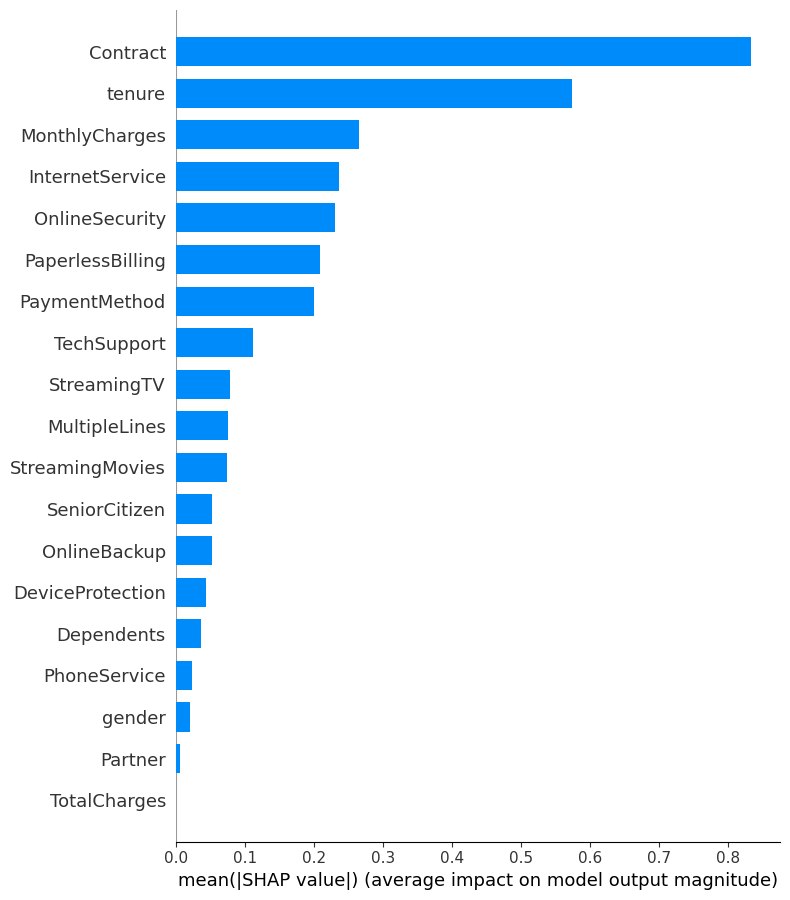

🐝 Affichage du graphique Beeswarm...


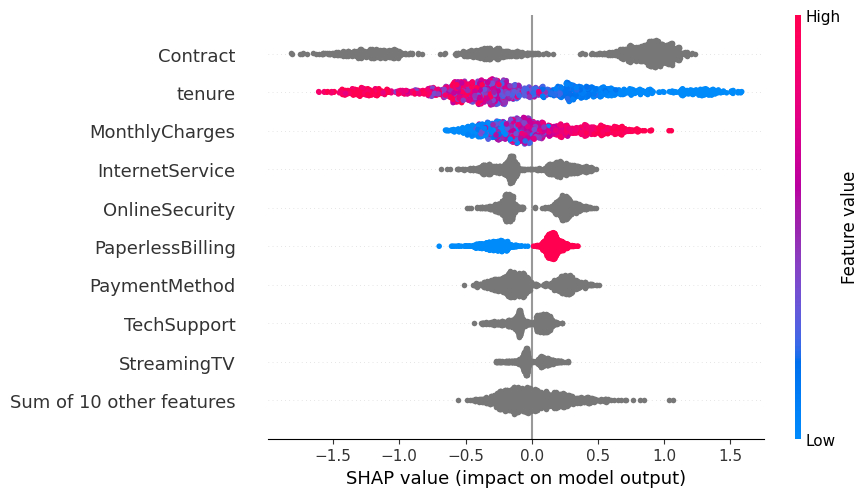

In [11]:
import matplotlib.pyplot as plt
import shap

# 1. Forcer Jupyter à afficher les graphiques directement sous la cellule
%matplotlib inline

# 2. Initialisation et calcul SHAP
explainer = shap.TreeExplainer(model)
print("🔮 Calcul des valeurs SHAP...")
shap_values = explainer(X_test)

# 3. Affichage du Graphique 1 (Importance globale sous forme de barres)
print("📊 Affichage du graphique de synthèse...")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

# 4. Affichage du Graphique 2 (Impact détaillé en Abeille / Beeswarm)
print("🐝 Affichage du graphique Beeswarm...")
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, show=True)

In [12]:
import pandas as pd
import numpy as np

# 1. On prend les données de test (X_test)
df_powerbi = X_test.copy()

# 2. On rajoute la vraie valeur (si le client est vraiment parti ou non)
df_powerbi['Vrai_Churn'] = y_test

# 3. On calcule la prédiction finale (0 ou 1) à partir des probabilités de y_pred
df_powerbi['Prediction_IA_Churn'] = (y_pred > 0.5).astype(int)

# 4. On exporte le tout dans un CSV propre sur ton Bureau
df_powerbi.to_csv("donnees_churn_ia_powerbi.csv", index=False, encoding='utf-8')

print("💾 Fichier généré avec succès ! Regarde sur ton Bureau, le fichier 'donnees_churn_ia_powerbi.csv' est apparu.")

💾 Fichier généré avec succès ! Regarde sur ton Bureau, le fichier 'donnees_churn_ia_powerbi.csv' est apparu.
